In [ ]:
#Regression → Classification Mapping

In [1]:
# =========================================================
# Regression → Classification Mapping
# (Full Code | From CSV Loading Start)
#
# Purpose:
# Verify whether regression-based continuous risk modeling
# can outperform direct classification after mapping back
# to 4-class labels.
#
# Output:
# 1. classification_report
# 2. confusion_matrix
# 3. comparison table with baseline classifier
# 4. saved txt report
#
# Required:
# best_dual_regression.pt
#
# =========================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
import os
import random
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")


# =========================================================
# Random Seed
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# =========================================================
# Device
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# Path Config
# =========================================================

LOCAL_MODEL_DIR = "./hf_models"
MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "roberta-base")
CHECKPOINT_PATH = "best_dual_regression.pt"


# =========================================================
# Load Dataset
# =========================================================

print("\nLoading dataset...")

df = pd.read_csv("mental_heath_unbanlanced.csv")

df = df.dropna(subset=["text", "status"])
df["text"] = df["text"].astype(str)

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["status"])

print("Label Mapping:")
for i, name in enumerate(label_encoder.classes_):
    print(f"{i} -> {name}")

"""
Confirmed mapping:
0 -> Anxiety
1 -> Depression
2 -> Normal
3 -> Suicidal
"""


# =========================================================
# Train / Val / Test Split
# =========================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df["label_encoded"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\nTrain size: {len(train_texts)}")
print(f"Val size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")


# =========================================================
# Dataset
# =========================================================

class RiskRegressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
            "text": self.texts[idx]
        }

        return item


# =========================================================
# Dual Regression Model
# =========================================================

class DualRegressionModel(nn.Module):
    def __init__(self, model_path):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_path,
            local_files_only=True
        )

        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.1)

        self.dep_head = nn.Linear(hidden, 1)
        self.sui_head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)

        dep_score = torch.sigmoid(
            self.dep_head(cls)
        ).squeeze(-1)

        sui_score = torch.sigmoid(
            self.sui_head(cls)
        ).squeeze(-1)

        return {
            "dep_score": dep_score,
            "sui_score": sui_score
        }


# =========================================================
# Score → 4-Class Mapping Rule
# =========================================================

def map_scores_to_class(dep_score, sui_score):
    """
    Final label mapping:

    2 -> Normal
    0 -> Anxiety
    1 -> Depression
    3 -> Suicidal
    """

    # Priority 1:
    # high suicidal risk

    if sui_score >= 0.70:
        return 3  # Suicidal

    # Priority 2:
    # strong depression

    elif dep_score >= 0.68:
        return 1  # Depression

    # Priority 3:
    # anxiety zone

    elif dep_score >= 0.30:
        return 0  # Anxiety

    # Priority 4:
    # low-risk

    else:
        return 2  # Normal


# =========================================================
# Load Model
# =========================================================

print("\nLoading regression model checkpoint...")

model = DualRegressionModel(MODEL_PATH).to(DEVICE)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Checkpoint loaded successfully.")


# =========================================================
# Tokenizer + Test Loader
# =========================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

test_dataset = RiskRegressionDataset(
    test_texts,
    test_labels,
    tokenizer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


# =========================================================
# Inference
# =========================================================

print("\nRunning inference on test set...")

all_preds = []
all_labels = []
all_dep_scores = []
all_sui_scores = []

with torch.no_grad():
    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].numpy()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        dep_scores = outputs["dep_score"].cpu().numpy()
        sui_scores = outputs["sui_score"].cpu().numpy()

        for d, s in zip(dep_scores, sui_scores):
            pred = map_scores_to_class(d, s)

            all_preds.append(pred)
            all_dep_scores.append(d)
            all_sui_scores.append(s)

        all_labels.extend(labels)


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


# =========================================================
# Evaluation
# =========================================================

print("\n====================================================")
print("Regression → Classification Results")
print("====================================================")

acc = accuracy_score(all_labels, all_preds)
weighted_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)
macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

print("\nClassification Report:\n")

report = classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_,
    digits=4
)

print(report)


# =========================================================
# Confusion Matrix
# =========================================================

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)


# =========================================================
# Compare with Best Direct Classification Model
# (RoBERTa baseline)
# =========================================================

print("\n====================================================")
print("Comparison with Best Classification Model")
print("====================================================")

print(f"{'Model':<40} {'Acc':<10} {'W-F1':<10} {'M-F1':<10}")
print("-" * 75)

print(
    f"{'RoBERTa Direct Classification':<40} "
    f"{0.8581:<10.4f} "
    f"{0.8584:<10.4f} "
    f"{0.8497:<10.4f}"
)

print(
    f"{'Regression → Classification Mapping':<40} "
    f"{acc:<10.4f} "
    f"{weighted_f1:<10.4f} "
    f"{macro_f1:<10.4f}"
)


# =========================================================
# Save Results
# =========================================================

save_path = "regression_to_classification_report.txt"

with open(save_path, "w", encoding="utf-8") as f:
    f.write("Regression → Classification Mapping Results\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"Weighted F1: {weighted_f1:.4f}\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n\n")

    f.write("Classification Report:\n")
    f.write(report)
    f.write("\n")

    f.write("Confusion Matrix:\n")
    f.write(str(cm))
    f.write("\n\n")

    f.write("Comparison with Baseline Classifier:\n")
    f.write(
        f"RoBERTa Direct Classification: "
        f"Acc=0.8581 | W-F1=0.8584 | M-F1=0.8497\n"
    )
    f.write(
        f"Regression Mapping: "
        f"Acc={acc:.4f} | W-F1={weighted_f1:.4f} | M-F1={macro_f1:.4f}\n"
    )

print(f"\nResults saved to: {save_path}")

print("\nExperiment 1 completed successfully.")


Using device: cuda

Loading dataset...
Label Mapping:
0 -> Anxiety
1 -> Depression
2 -> Normal
3 -> Suicidal

Train size: 34728
Val size: 7442
Test size: 7442

Loading regression model checkpoint...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ./hf_models\roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint loaded successfully.

Running inference on test set...


100%|██████████████████████████████████████████████████████████████████████████████| 233/233 [00:22<00:00, 10.45it/s]


Regression → Classification Results
Accuracy: 0.8512
Weighted F1: 0.8505
Macro F1: 0.8342

Classification Report:

              precision    recall  f1-score   support

     Anxiety     0.7370    0.9128    0.8156       826
  Depression     0.8204    0.7243    0.7693      2176
      Normal     0.9620    0.9627    0.9623      2758
    Suicidal     0.7768    0.8026    0.7895      1682

    accuracy                         0.8512      7442
   macro avg     0.8240    0.8506    0.8342      7442
weighted avg     0.8537    0.8512    0.8505      7442

Confusion Matrix:
[[ 754   30   40    2]
 [ 187 1576   41  372]
 [  63   26 2655   14]
 [  19  289   24 1350]]

Comparison with Best Classification Model
Model                                    Acc        W-F1       M-F1      
---------------------------------------------------------------------------
RoBERTa Direct Classification            0.8581     0.8584     0.8497    
Regression → Classification Mapping      0.8512     0.8505     0.8342  

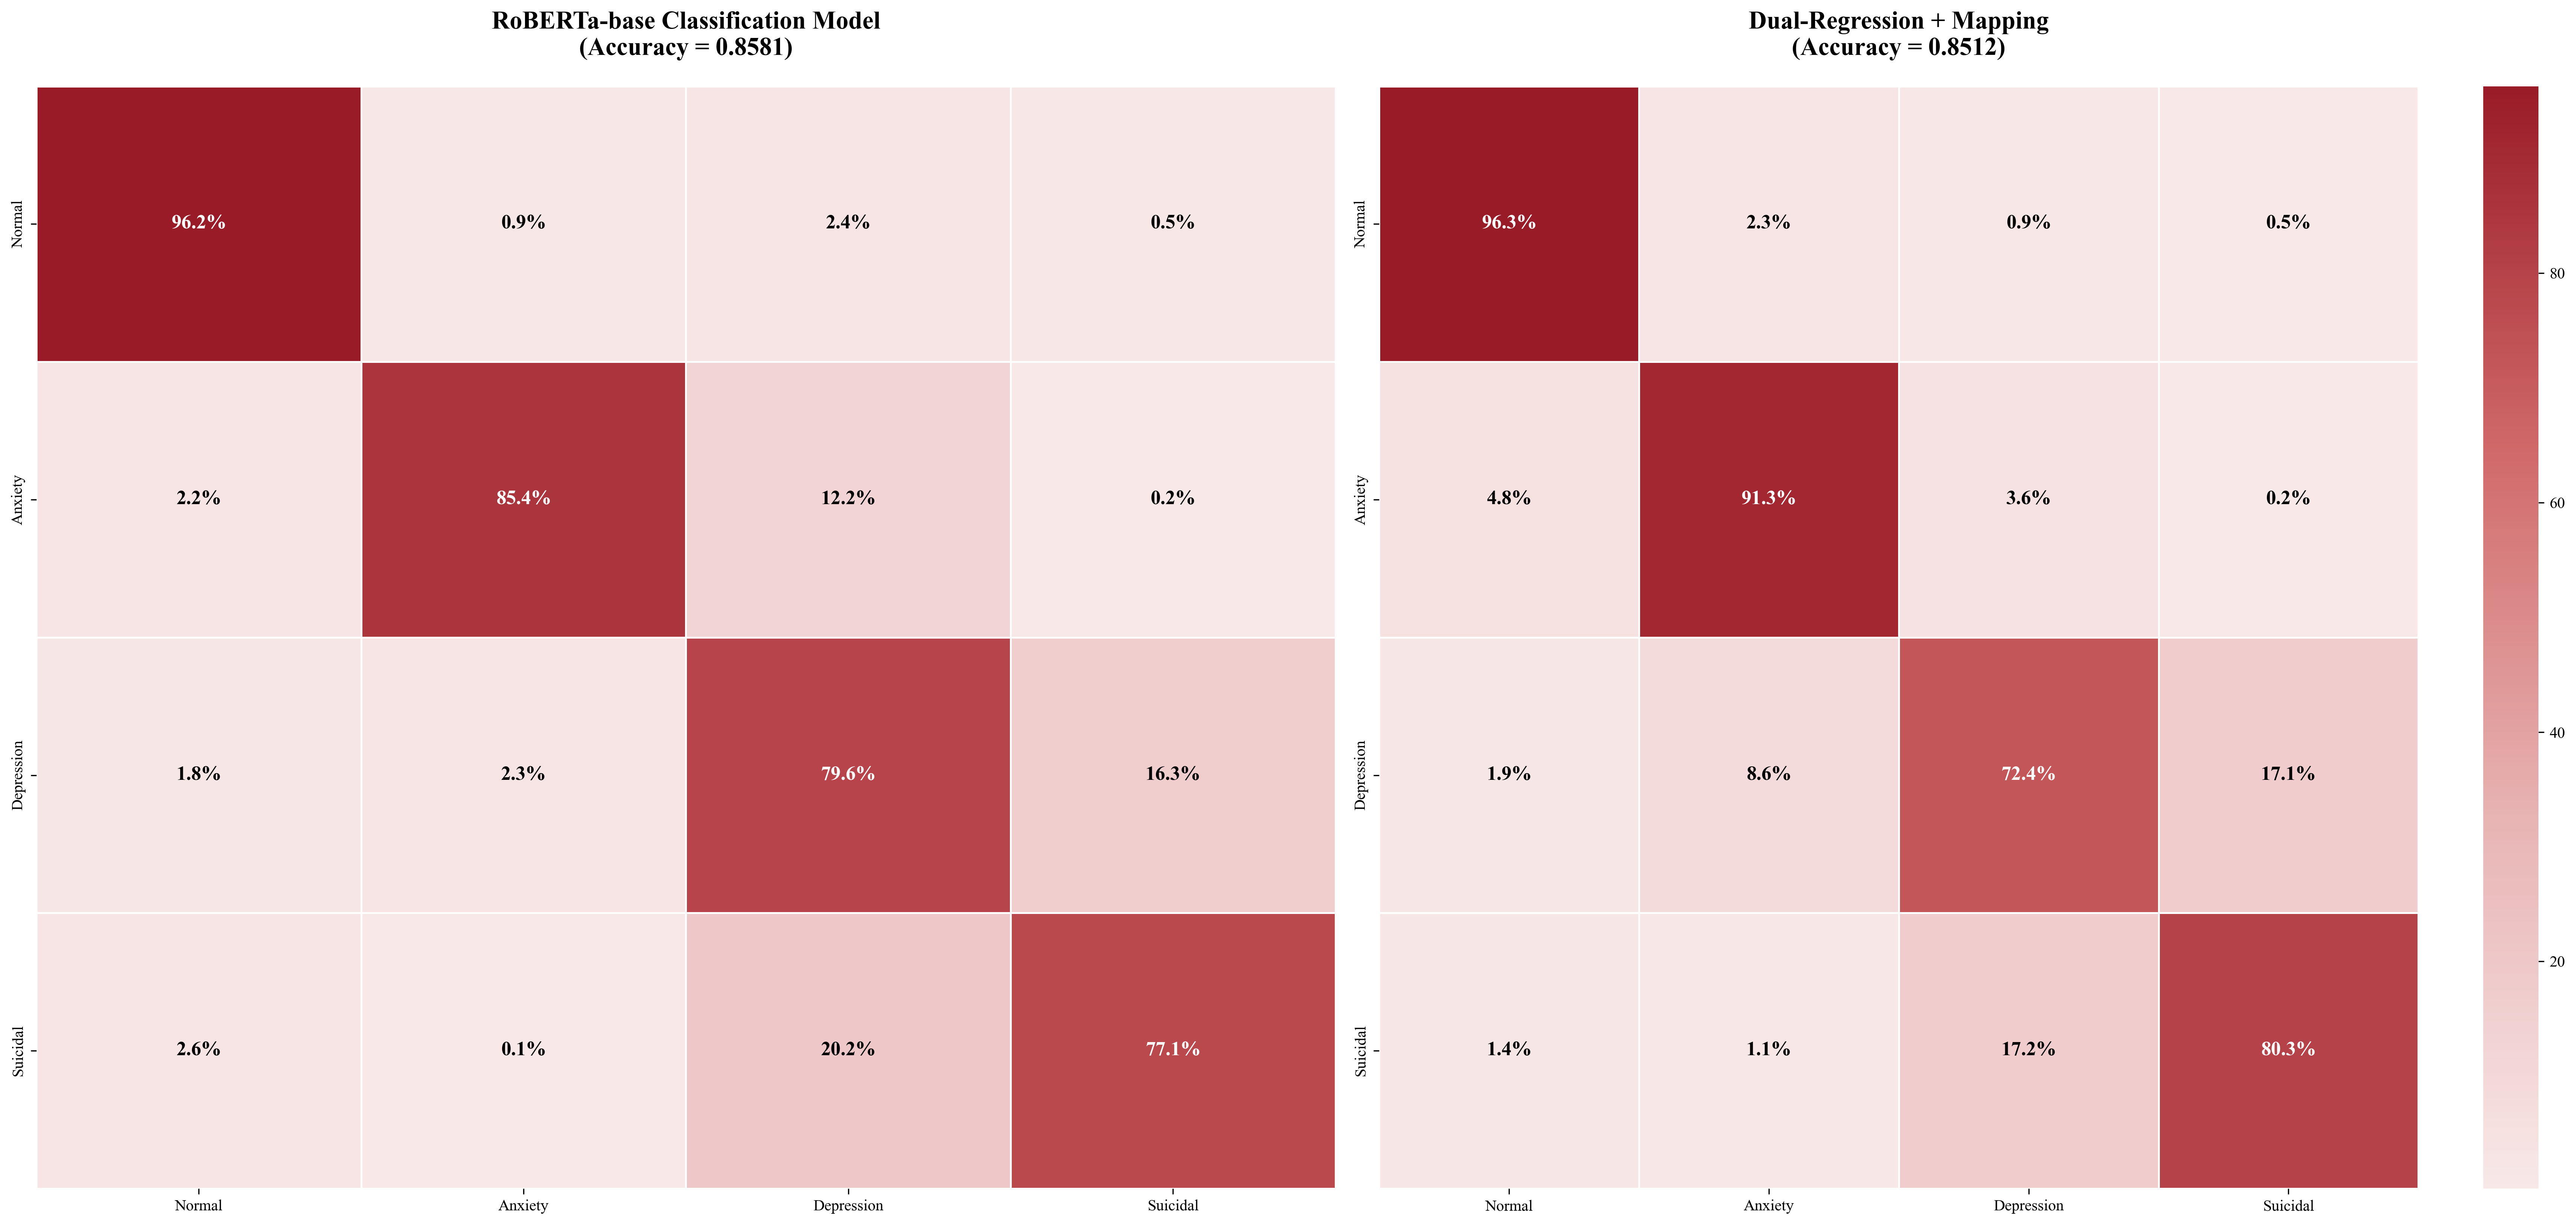

Classification Model - 对角线 Recall: [96.2 85.4 79.6 77.1]
Regression Mapping   - 对角线 Recall: [96.3 91.3 72.4 80.3]


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ==================== 数据准备 ====================

# 1. RoBERTa-base 分类模型混淆矩阵 (按 Normal → Anxiety → Depression → Suicidal 排序)
cm_class = np.array([
    [2653,  24,  67,  14],   # True: Normal
    [  18, 705, 101,   2],   # True: Anxiety
    [  40,  49,1732, 355],   # True: Depression
    [  44,   2, 340,1296]    # True: Suicidal
])

# 2. Dual-Regression 映射后的混淆矩阵
cm_reg = np.array([
    [2655,  63,  26,  14],   # True: Normal
    [  40, 754,  30,   2],   # True: Anxiety
    [  41, 187,1576, 372],   # True: Depression
    [  24,  19, 289,1350]    # True: Suicidal
])

class_names = ['Normal', 'Anxiety', 'Depression', 'Suicidal']

# 计算行百分比
cm_class_p = (cm_class.astype(float) / cm_class.sum(axis=1, keepdims=True) * 100).round(1)
cm_reg_p   = (cm_reg.astype(float) / cm_reg.sum(axis=1, keepdims=True) * 100).round(1)

# ==================== 自定义配色 (#991B27 主色) ====================
colors = ['#F8E8E8', '#E8B4B4', '#D16A6A', '#991B27']
custom_cmap = LinearSegmentedColormap.from_list('custom_991B27', colors, N=256)

# ==================== 绘图 ====================
fig, axes = plt.subplots(1, 2, figsize=(24, 11))

# ------------------- 左图：RoBERTa-base 分类模型 -------------------
sns.heatmap(cm_class_p, annot=False, cmap=custom_cmap, ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.2, linecolor='white', cbar=False)

for i in range(4):
    for j in range(4):
        p = cm_class_p[i, j]
        color = 'white' if p > 45 else 'black'
        axes[0].text(j + 0.5, i + 0.5, f'{p:.1f}%', 
                     ha='center', va='center', color=color, 
                     fontsize=12.8, fontweight='bold')

axes[0].set_title('RoBERTa-base Classification Model\n(Accuracy = 0.8581)', 
                  fontsize=16, pad=20, fontweight='bold')

# ------------------- 右图：Dual-Regression 映射后 -------------------
sns.heatmap(cm_reg_p, annot=False, cmap=custom_cmap, ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.2, linecolor='white')

for i in range(4):
    for j in range(4):
        p = cm_reg_p[i, j]
        color = 'white' if p > 45 else 'black'
        axes[1].text(j + 0.5, i + 0.5, f'{p:.1f}%', 
                     ha='center', va='center', color=color, 
                     fontsize=12.8, fontweight='bold')

axes[1].set_title('Dual-Regression + Mapping\n(Accuracy = 0.8512)', 
                  fontsize=16, pad=20, fontweight='bold')

#plt.suptitle('Comparison of Confusion Matrices\n'
#             '(Row-normalized percentages | Classes ordered by increasing severity)', 
#             fontsize=18.5, fontweight='bold', y=1.03)

plt.tight_layout()
plt.savefig('Figure_Confusion_Matrix_Comparison_991B27.png', dpi=450, bbox_inches='tight')
plt.show()

# 验证
print("Classification Model - 对角线 Recall:", cm_class_p.diagonal())
print("Regression Mapping   - 对角线 Recall:", cm_reg_p.diagonal())

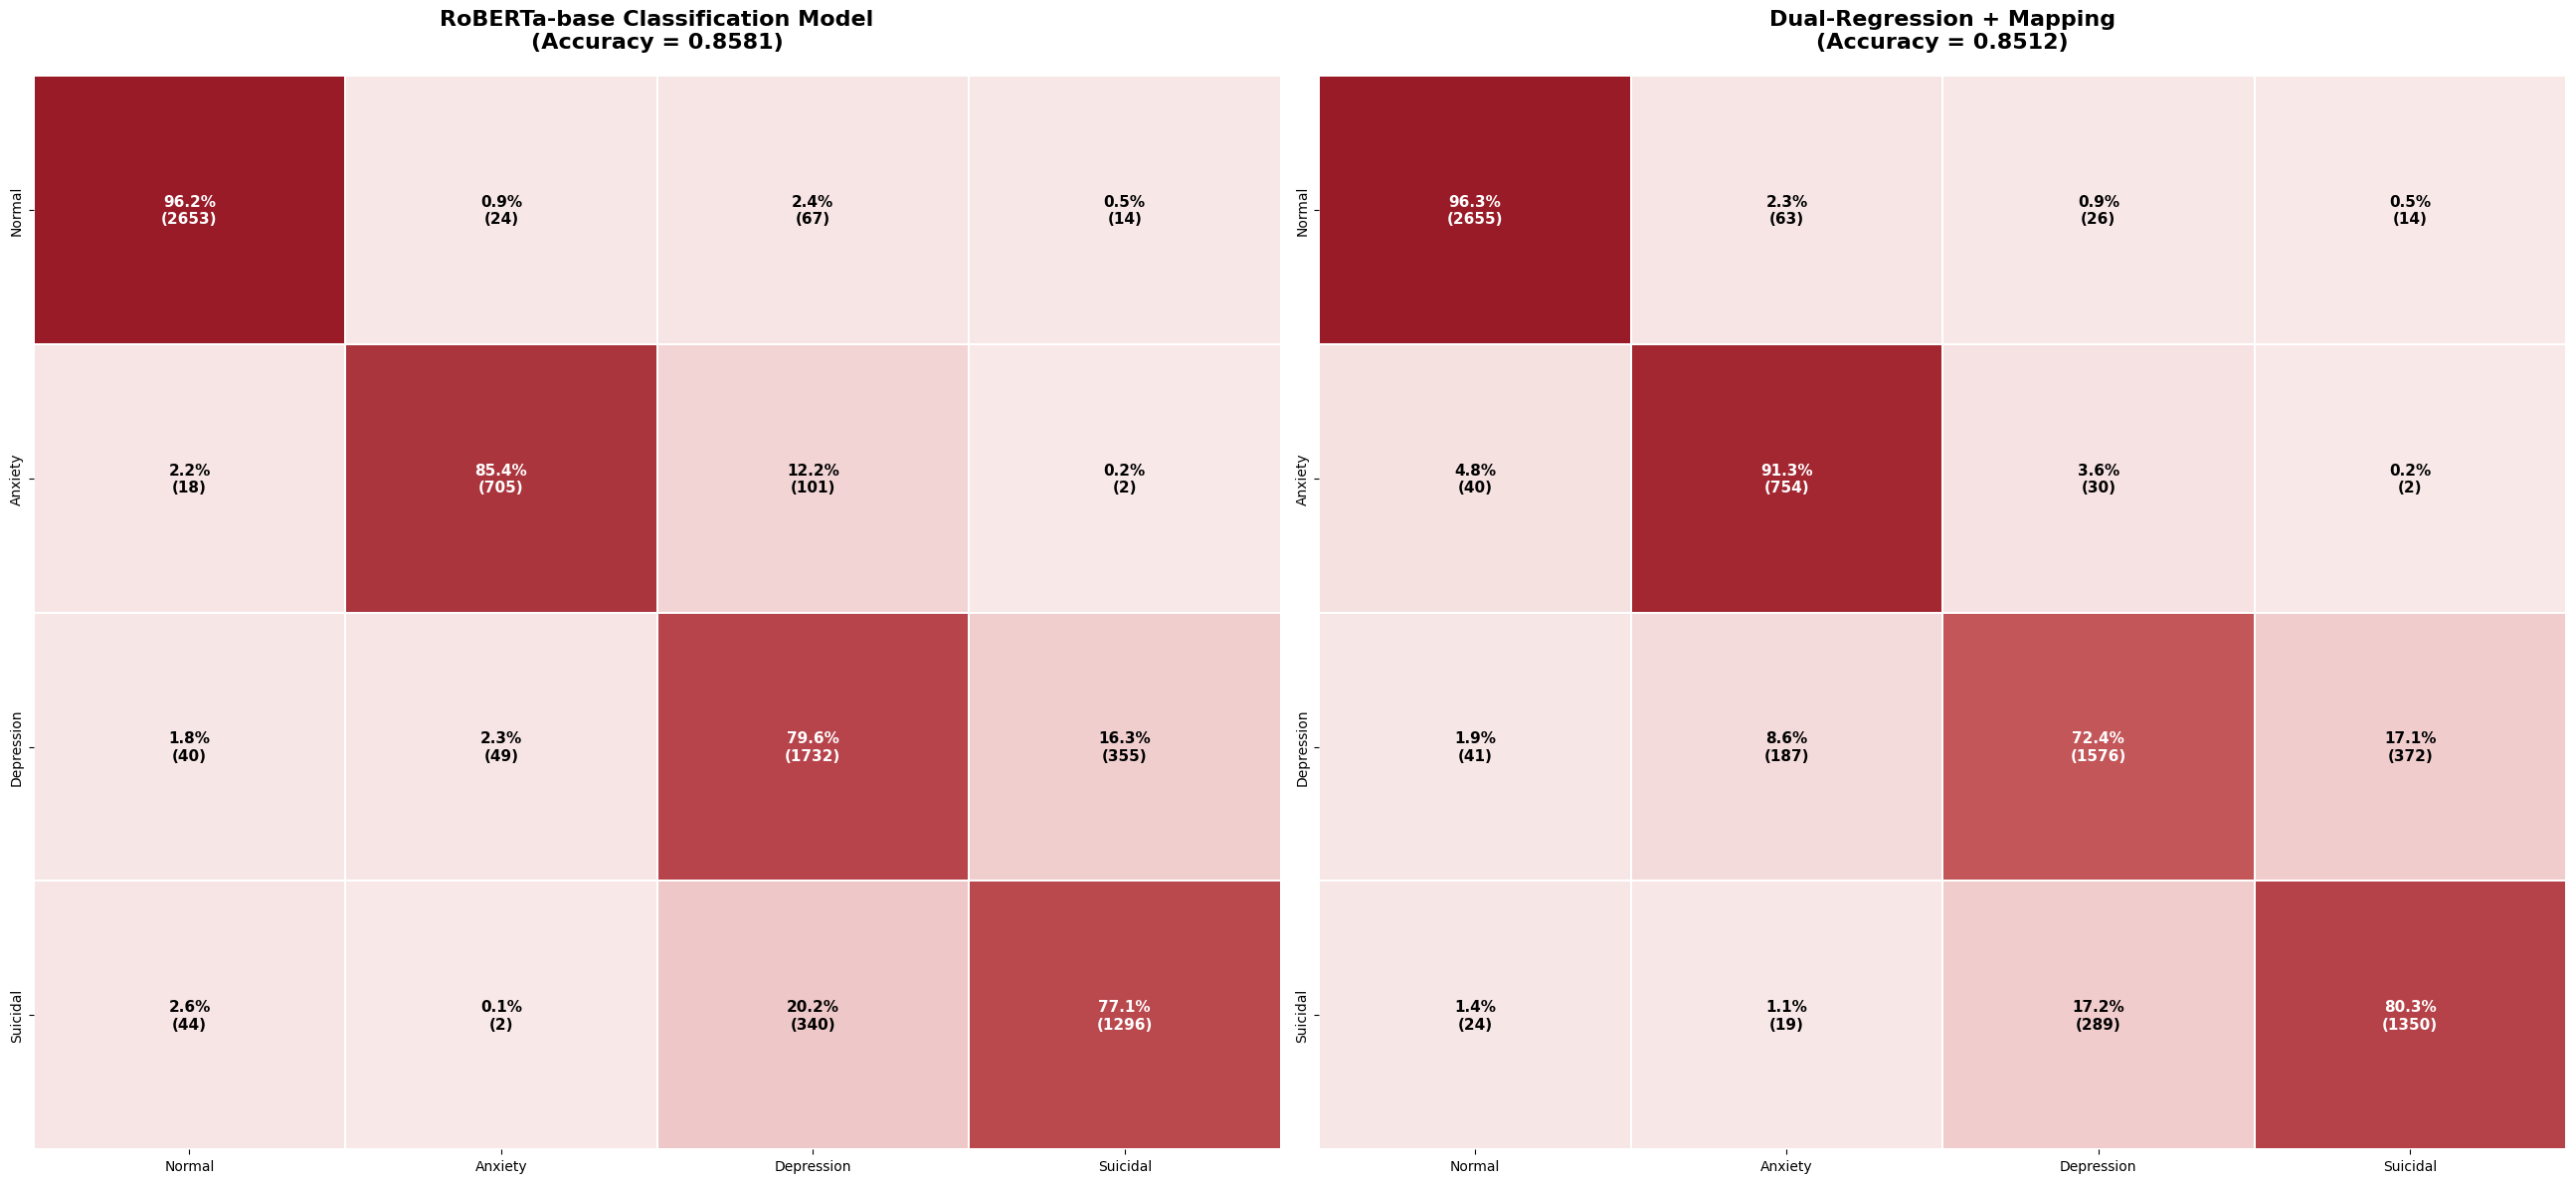

Classification Model - Recall: [96.2 85.4 79.6 77.1]
Regression Mapping - Recall: [96.3 91.3 72.4 80.3]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ==================== 数据准备 ====================
cm_class = np.array([
    [2653, 24, 67, 14],   # True: Normal
    [18, 705, 101, 2],    # True: Anxiety
    [40, 49, 1732, 355],  # True: Depression
    [44, 2, 340, 1296]    # True: Suicidal
])

cm_reg = np.array([
    [2655, 63, 26, 14],
    [40, 754, 30, 2],
    [41, 187, 1576, 372],
    [24, 19, 289, 1350]
])

class_names = ['Normal', 'Anxiety', 'Depression', 'Suicidal']

# 计算行百分比
cm_class_p = (cm_class.astype(float) / cm_class.sum(axis=1, keepdims=True) * 100).round(1)
cm_reg_p = (cm_reg.astype(float) / cm_reg.sum(axis=1, keepdims=True) * 100).round(1)

# ==================== 自定义配色 ====================
colors = ['#F8E8E8', '#E8B4B4', '#D16A6A', '#991B27']
custom_cmap = LinearSegmentedColormap.from_list('custom_991B27', colors, N=256)

# ==================== 绘图函数 ====================
def plot_cm_with_both(cm, cm_p, ax, title):
    sns.heatmap(cm_p, annot=False, cmap=custom_cmap, ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1.2, linecolor='white', cbar=False)
    
    for i in range(4):
        for j in range(4):
            count = cm[i, j]
            p = cm_p[i, j]
            text = f'{p:.1f}%\n({count})'
            color = 'white' if p > 45 else 'black'
            ax.text(j + 0.5, i + 0.5, text,
                    ha='center', va='center', color=color,
                    fontsize=11, fontweight='bold')   # 字体稍调小以适应两行文本

    ax.set_title(title, fontsize=16, pad=20, fontweight='bold')

# ==================== 创建图像 ====================
fig, axes = plt.subplots(1, 2, figsize=(26, 12))   # 稍微加宽适应更多文本

plot_cm_with_both(cm_class, cm_class_p, axes[0],
                  'RoBERTa-base Classification Model\n(Accuracy = 0.8581)')

plot_cm_with_both(cm_reg, cm_reg_p, axes[1],
                  'Dual-Regression + Mapping\n(Accuracy = 0.8512)')

plt.tight_layout()
plt.savefig('Figure_Confusion_Matrix_Comparison_991B27_Both.png', dpi=450, bbox_inches='tight')
plt.show()

# 验证
print("Classification Model - Recall:", cm_class_p.diagonal())
print("Regression Mapping - Recall:", cm_reg_p.diagonal())